## ``DL-Regression Model - FIFA``

##### ``Sandra Ranilla-Cortina``

In [1]:
# Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

plt.style.use('fivethirtyeight')
np.random.seed(777)

import warnings
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = FutureWarning)

#### ``Exploratory Data Analysis (EDA)``

In [2]:
# NVIDIA Stock Price 5Y dataset
df_nvidia = pd.read_csv('https://raw.githubusercontent.com/sranillac/SRC_UniOvi/refs/heads/main/ML-DL/data/FIFA/FIFA-Dataset.csv', usecols = lambda column: column != 'Unnamed: 0')
df_nvidia['date'] = pd.to_datetime(df_nvidia['date'])
df_nvidia = df_nvidia.sort_values('date')
df_nvidia.head(5)

KeyError: 'date'

In [3]:
# Daily return (yield) and trading volume return
df_nvidia['yield'] = df_nvidia['close'].pct_change()
df_nvidia['trading_volume_return'] = df_nvidia['volume'].pct_change()
df_nvidia.dropna(inplace = True) # drop first line

In [4]:
# Features type
df_nvidia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1258 entries, 1 to 1258
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1258 non-null   datetime64[ns]
 1   open                   1258 non-null   float64       
 2   high                   1258 non-null   float64       
 3   low                    1258 non-null   float64       
 4   close                  1258 non-null   float64       
 5   volume                 1258 non-null   int64         
 6   Name                   1258 non-null   object        
 7   yield                  1258 non-null   float64       
 8   trading_volume_return  1258 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 98.3+ KB


In [5]:
# Features description
df_nvidia[['open', 'high', 'low', 'close', 'volume', 'yield', 'trading_volume_return']].describe()

,open,high,low,close,volume,yield,trading_volume_return
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.000000,1258.000000
mean,56.351479,57.106773,55.547462,56.404344,1.046802e+07,0.002563,0.083750
std,59.600953,60.428109,58.648437,59.635432,7.205539e+06,0.022350,0.477835
min,12.070000,12.290000,12.040000,12.126000,1.141128e+06,-0.092723,-0.759334
25%,18.345000,18.580000,18.180075,18.365000,6.162788e+06,-0.007525,-0.220822
50%,22.635000,22.840000,22.377500,22.675000,8.419236e+06,0.001673,-0.030458
75%,71.382500,72.027500,70.418750,71.160000,1.202712e+07,0.011983,0.251142
max,245.770000,249.270000,244.450000,246.850000,9.232320e+07,0.298067,3.196751


#### ``Visualization``

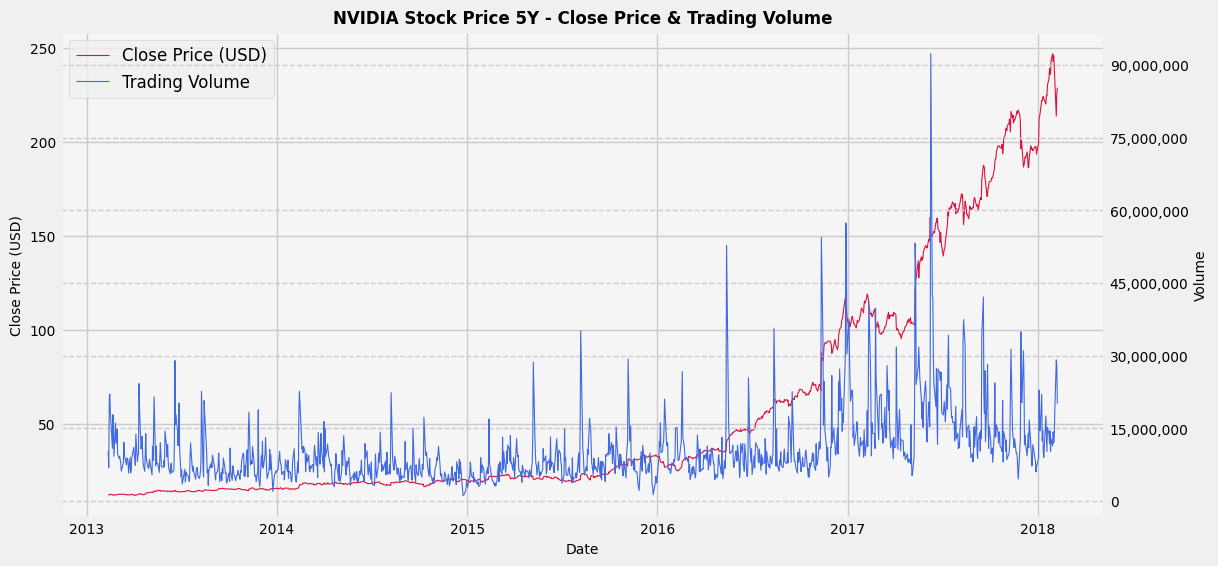

In [6]:
# Visualization - NVIDIA Stock Price 5Y (Close Price & Trading Volume)
fig = plt.figure(figsize = (12, 6))
ax1 = fig.gca()
ax1.set_facecolor('whitesmoke')
line1, = ax1.plot(df_nvidia['date'], df_nvidia['close'], label = 'Close Price', color = 'crimson', linewidth = 0.8)
ax1.set_ylabel('Close Price (USD)', fontsize = 10)
ax1.tick_params(axis = 'y', labelsize = 10)
ax2 = ax1.twinx()
line2, = ax2.plot(df_nvidia['date'], df_nvidia['volume'], label = 'Trading Volume', color = 'royalblue', linewidth = 0.8)
ax2.set_ylabel('Volume', fontsize = 10)
ax2.tick_params(axis = 'y', labelsize = 10)
ax2.yaxis.set_major_locator(MaxNLocator(integer = True))
ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.grid(linestyle = '--')
plt.title('NVIDIA Stock Price 5Y - Close Price & Trading Volume', fontsize = 12, fontweight = 'bold')
ax1.set_xlabel('Date', fontsize = 10)
ax1.tick_params(axis = 'x', labelsize = 10)
handles = [line1, line2]
labels = ['Close Price (USD)', 'Trading Volume']
legend = ax1.legend(handles = handles, labels = labels, loc = 'upper left', frameon = True, prop = {'size': 12})
legend.get_frame().set_linewidth(0.5);

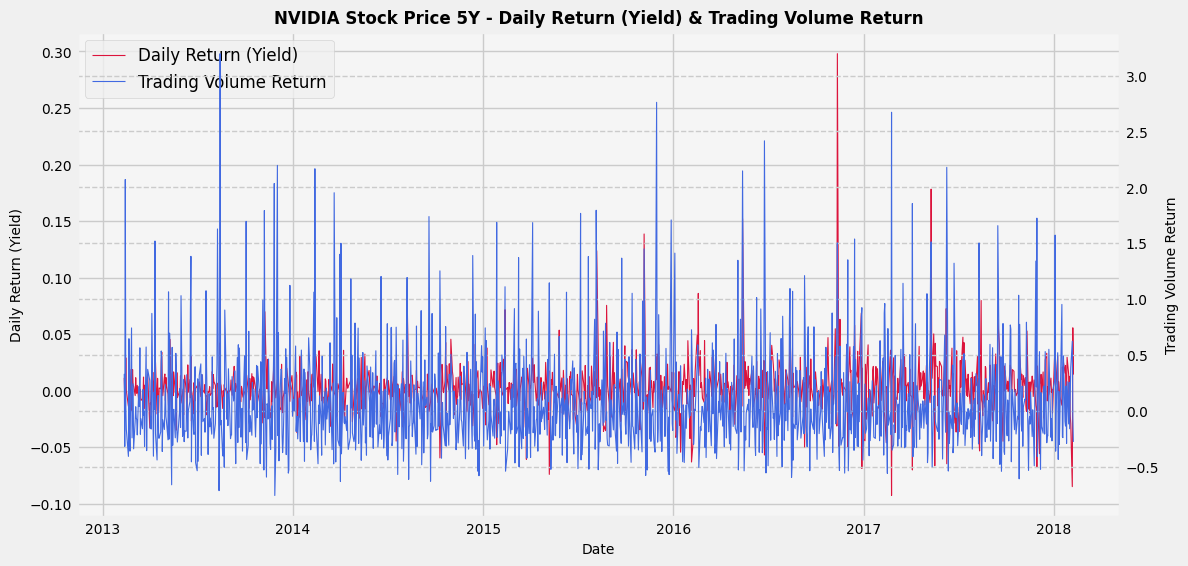

In [7]:
# Visualization - NVIDIA Stock Price 5Y (Daily Return-Yield & Trading Volume Return)
fig = plt.figure(figsize = (12, 6))
ax1 = fig.gca()
ax1.set_facecolor('whitesmoke')
line1, = ax1.plot(df_nvidia['date'], df_nvidia['yield'], label = 'Daily Return (Yield)', color = 'crimson', linewidth = 0.8)
ax1.set_ylabel('Daily Return (Yield)', fontsize = 10)
ax1.tick_params(axis = 'y', labelsize = 10)
ax2 = ax1.twinx()
line2, = ax2.plot(df_nvidia['date'], df_nvidia['trading_volume_return'], label = 'Trading Volume Return', color = 'royalblue', linewidth = 0.8)
ax2.set_ylabel('Trading Volume Return', fontsize = 10)
ax2.tick_params(axis = 'y', labelsize = 10)
plt.grid(linestyle = '--')
plt.title('NVIDIA Stock Price 5Y - Daily Return (Yield) & Trading Volume Return', fontsize = 12, fontweight = 'bold')
ax1.set_xlabel('Date', fontsize = 10)
ax1.tick_params(axis = 'x', labelsize = 10)
handles = [line1, line2]
labels = ['Daily Return (Yield)', 'Trading Volume Return']
legend = ax1.legend(handles = handles, labels = labels, loc = 'upper left', frameon = True, prop = {'size': 12})
legend.get_frame().set_linewidth(0.5);


#### ``Data Pre-Processing``

In [8]:
# NA-values
for col in df_nvidia.columns.tolist():          
    print('{} column missing values: {}'.format(col, df_nvidia[col].isnull().sum()))

date column missing values: 0
open column missing values: 0
high column missing values: 0
low column missing values: 0
close column missing values: 0
volume column missing values: 0
Name column missing values: 0
yield column missing values: 0
trading_volume_return column missing values: 0


In [9]:
# Create new features
df_nvidia['day'] = df_nvidia['date'].dt.day
df_nvidia['month'] = df_nvidia['date'].dt.month
df_nvidia['year'] = df_nvidia['date'].dt.year
print(df_nvidia.shape)

(1258, 12)


In [10]:
# Feature Selection + Target
X = df_nvidia.drop(['date', 'yield', 'trading_volume_return', 'close', 'Name'], axis = 1)
Y = df_nvidia['close']
print(X.shape)
print(Y.shape)

(1258, 7)
(1258,)


In [11]:
# Numerical features
sc = StandardScaler()

numerical_variables = ['open', 'high', 'low', 'volume']
for col in numerical_variables:
    X[[col]] = sc.fit_transform(X[[col]])
X.head()

,open,high,low,volume,day,month,year
1,-0.736547,-0.736238,-0.736842,-0.036156,11,2,2013
2,-0.737806,-0.737397,-0.736330,-0.489117,12,2,2013
3,-0.737051,-0.735741,-0.737183,1.507017,13,2,2013
4,-0.741079,-0.734500,-0.741959,1.607919,14,2,2013
5,-0.732687,-0.733672,-0.735136,1.093822,15,2,2013


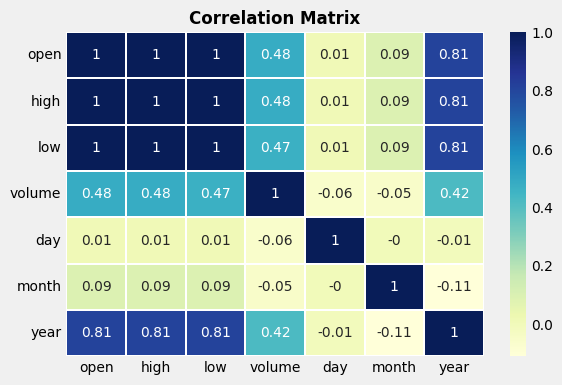

In [12]:
# Correlation Matrix
mcorr = X.corr().round(2)
fig = plt.figure(figsize = (6, 4))
sns.heatmap(mcorr, annot = True, linewidth = 0.2, cmap = 'YlGnBu', annot_kws = {'size': 10})
plt.title('Correlation Matrix', fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize = 10)

In [13]:
# Train-vs-Test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 1)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(943, 7)
(943,)
(315, 7)
(315,)


#### ``Modeling``

In [14]:
# Neural Network model
model_nn = Sequential(name = 'Model_NN')

model_nn.add(Dense(256, activation = 'relu', input_shape = (X_train.shape[1],), kernel_regularizer=regularizers.l2(0.001), name = 'hidden_layer_1'))
model_nn.add(Dropout(0.2, name = 'dropout_1'))

model_nn.add(Dense(128, activation = 'relu', kernel_regularizer = regularizers.l2(0.001), name = 'hidden_layer_2'))
model_nn.add(Dropout(0.2, name = 'dropout_2'))

model_nn.add(Dense(128, activation = 'relu', kernel_regularizer = regularizers.l2(0.001), name = 'hidden_layer_3'))
model_nn.add(Dropout(0.2, name = 'dropout_3'))

model_nn.add(Dense(64, activation = 'relu', kernel_regularizer = regularizers.l2(0.001), name = 'hidden_layer_4'))
model_nn.add(Dropout(0.2, name = 'dropout_4'))

model_nn.add(Dense(32, activation = 'relu', name = 'hidden_layer_5'))

model_nn.add(Dense(1, name = 'output_layer'))

model_nn.summary()

Model: "Model_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 256)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_4 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_5 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,825 (241.50 KB)

 Trainable params: 61,825 (241.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Compilation + Training
model_nn.compile(loss = 'mae', optimizer = Adam(learning_rate = 0.002), metrics = ['mse'])
history_nn = model_nn.fit(X_train, Y_train, epochs = 1000, batch_size = 64, validation_split = 0.2, verbose = 1)

Epoch 1/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 55.2499 - mse: 5715.6006 - val_loss: 43.8915 - val_mse: 5575.2476
Epoch 2/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 41.2509 - mse: 4271.6309 - val_loss: 43.0251 - val_mse: 5345.4043
Epoch 3/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 40.7001 - mse: 4477.3540 - val_loss: 44.8195 - val_mse: 5724.1079
Epoch 4/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 40.9155 - mse: 4602.2017 - val_loss: 46.9339 - val_mse: 5985.5781
Epoch 5/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36.4228 - mse: 4017.2917 - val_loss: 42.8530 - val_mse: 5221.8579
Epoch 6/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 39.8876 - mse: 4224.1772 - val_loss: 46.0479 - val_mse: 5885.3887
Epoch 7/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 38.0484 - mse: 4134.6226 - val_loss: 43.3517 - val_mse: 5475.5479
Epoch 8/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 42.5783 - mse: 4960.6489 - val_loss: 44.9711 - val_mse: 5

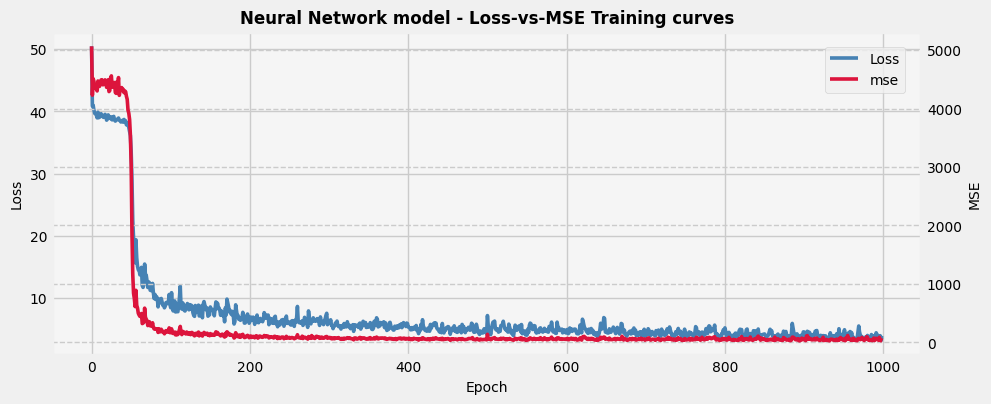

In [16]:
# Loss-vs-MSE Training curves
fig = plt.figure(figsize = (10, 4))
ax1 = fig.gca()
ax1.set_facecolor('whitesmoke')
ax1.plot(history_nn.history['loss'], label = 'Loss', color = 'steelblue', linewidth = 2.6)
ax1.set_ylabel('Loss', fontsize = 10)
ax1.tick_params(axis = 'y', labelsize = 10)
ax2 = ax1.twinx()
ax2.plot(history_nn.history['mse'], label = 'mse', color = 'crimson', linewidth = 2.6)
ax2.set_ylabel('MSE', fontsize = 10)
ax2.tick_params(axis = 'y', labelsize = 10)
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))
ax1.set_xlabel('Epoch', fontsize = 10)
ax1.tick_params(axis = 'x', labelsize = 10)
plt.title('Neural Network model - Loss-vs-MSE Training curves', fontsize = 12, fontweight = 'bold')
plt.grid(linestyle = '--')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc = 'upper right', bbox_to_anchor = (0.94, 0.86), fontsize = 10)
legend.get_frame().set_linewidth(0.5);

In [17]:
# Model Prediction
y_test_pred = model_nn.predict(X_test, verbose = 0).flatten()

# Evaluation
mae_dt = mean_absolute_error(Y_test, y_test_pred)
mse_dt = mean_squared_error(Y_test, y_test_pred)
print(f'Neural Network model \n -> MAE = {mae_dt:.4f} \n -> MSE = {mse_dt:.4f}')

Neural Network model 
 -> MAE = 26.1072 
 -> MSE = 1791.5680


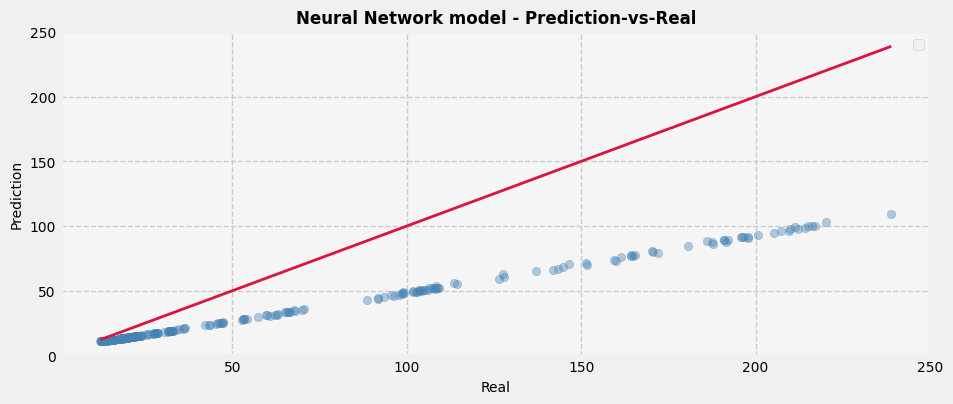

In [18]:
# Prediction-vs-Real
fig = plt.figure(figsize = (10, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
ax.scatter(Y_test, y_test_pred, color = 'steelblue', alpha = 0.4)
ax.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color = 'crimson', linewidth = 2) # reference line
ax.set_ylabel('Prediction', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
ax.set_xlabel('Real', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
plt.title('Neural Network model - Prediction-vs-Real', fontsize = 12, fontweight = 'bold')
plt.grid(linestyle = '--')
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

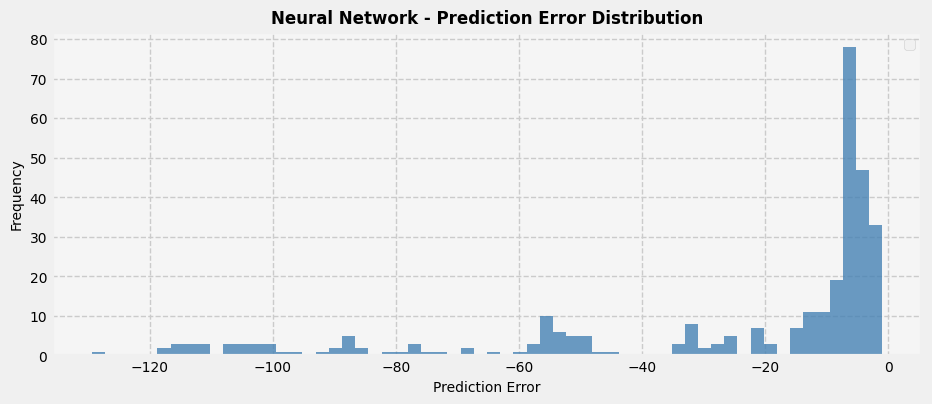

In [19]:
# Prediction Error
errors = y_test_pred - Y_test
fig = plt.figure(figsize = (10, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
ax.hist(errors, bins = 60, color = 'steelblue', alpha = 0.8)
ax.set_ylabel('Frequency', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
ax.set_xlabel('Prediction Error', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
plt.title('Neural Network - Prediction Error Distribution', fontsize = 12, fontweight = 'bold')
plt.grid(linestyle = '--')
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

In [ ]:
# Convolutional Neural Network model

X_train = X_train.values.reshape(-1, X_train.shape[1], 1)
X_test = X_test.values.reshape(-1, X_test.shape[1], 1)
Y_train = Y_train.values.reshape(-1, 1)
Y_test = Y_test.values.reshape(-1, 1)

model_cnn = Sequential(name = 'Model_CNN')

model_cnn.add(Conv1D(64, 3, activation = 'relu', input_shape = (X_train.shape[1], 1), padding = 'same', kernel_regularizer = regularizers.l2(0.001), name = 'cnn_layer_1'))
model_cnn.add(MaxPooling1D(2, name = 'maxpool_1'))
model_cnn.add(Dropout(0.2, name = 'dropout_1'))

model_cnn.add(Conv1D(128, 3, activation = 'relu', padding = 'same', kernel_regularizer = regularizers.l2(0.001), name = 'cnn_layer_2'))
model_cnn.add(MaxPooling1D(2, name = 'maxpool_2'))
model_cnn.add(Dropout(0.2, name = 'dropout_2'))

model_cnn.add(Conv1D(256, 3, activation = 'relu', padding = 'same', kernel_regularizer = regularizers.l2(0.001), name = 'cnn_layer_3'))
model_cnn.add(Dropout(0.2, name = 'dropout_3'))

model_cnn.add(Flatten(name = 'flatten_layer'))

model_cnn.add(Dense(128, activation = 'relu', kernel_regularizer = regularizers.l2(0.001), name = 'hidden_layer_1'))
model_cnn.add(Dropout(0.2, name = 'dropout_4'))

model_cnn.add(Dense(64, activation = 'relu', kernel_regularizer = regularizers.l2(0.001), name = 'hidden_layer_2'))
model_cnn.add(Dropout(0.2, name = 'dropout_5'))

model_cnn.add(Dense(1, name = 'output_layer'))

model_cnn.summary()

Model: "Model_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cnn_layer_1 (Conv1D)            │ (None, 7, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling1D)        │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_layer_2 (Conv1D)            │ (None, 3, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling1D)        │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_layer_3 (Conv1D)            │ (None, 1, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_layer (Flatten)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,737 (643.50 KB)

 Trainable params: 164,737 (643.50 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Compilation + Training
model_cnn.compile(loss = 'mae', optimizer = Adam(learning_rate = 0.002), metrics = ['mse'])
history_cnn = model_cnn.fit(X_train, Y_train, epochs = 1000, batch_size = 64, validation_split = 0.2, verbose = 1)

Epoch 1/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 54.1390 - mse: 5690.4878 - val_loss: 43.3312 - val_mse: 4730.5020
Epoch 2/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 41.3443 - mse: 4546.8359 - val_loss: 43.4701 - val_mse: 5481.1157
Epoch 3/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 37.1605 - mse: 3959.8777 - val_loss: 45.2440 - val_mse: 5765.0088
Epoch 4/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 40.3620 - mse: 4599.5107 - val_loss: 43.6007 - val_mse: 5507.0034
Epoch 5/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 38.6630 - mse: 4425.5005 - val_loss: 44.6772 - val_mse: 5654.9902
Epoch 6/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 37.7265 - mse: 4186.2563 - val_loss: 42.4202 - val_mse: 5235.0938
Epoch 7/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 37.4320 - mse: 3933.7969 - val_loss: 42.7378 - val_mse: 5117.9854
Epoch 8/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 37.6139 - mse: 3936.1177 - val_loss: 34.8294 - val_mse: 3

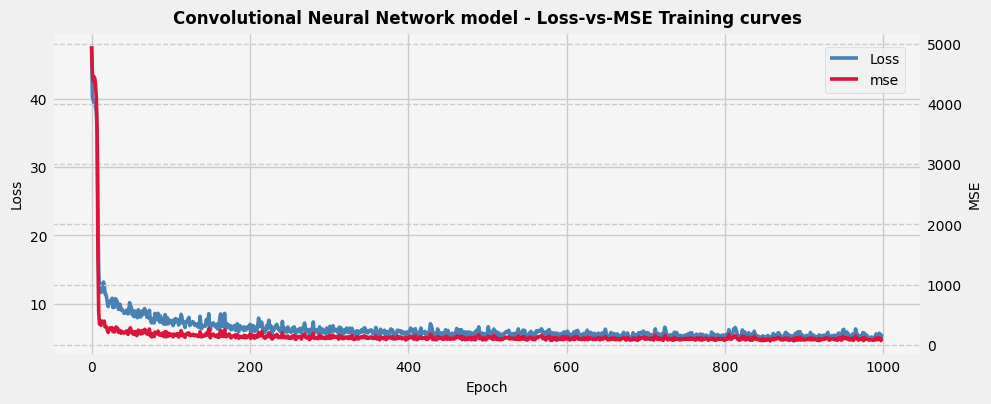

In [22]:
# Loss-vs-MSE Training curves
fig = plt.figure(figsize = (10, 4))
ax1 = fig.gca()
ax1.set_facecolor('whitesmoke')
ax1.plot(history_cnn.history['loss'], label = 'Loss', color = 'steelblue', linewidth = 2.6)
ax1.set_ylabel('Loss', fontsize = 10)
ax1.tick_params(axis = 'y', labelsize = 10)
ax2 = ax1.twinx()
ax2.plot(history_cnn.history['mse'], label = 'mse', color = 'crimson', linewidth = 2.6)
ax2.set_ylabel('MSE', fontsize = 10)
ax2.tick_params(axis = 'y', labelsize = 10)
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))
ax1.set_xlabel('Epoch', fontsize = 10)
ax1.tick_params(axis = 'x', labelsize = 10)
plt.title('Convolutional Neural Network model - Loss-vs-MSE Training curves', fontsize = 12, fontweight = 'bold')
plt.grid(linestyle = '--')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc = 'upper right', bbox_to_anchor = (0.94, 0.86), fontsize = 10)
legend.get_frame().set_linewidth(0.5);

In [23]:
# Model Prediction
Y_test = Y_test.flatten()
y_test_pred = model_cnn.predict(X_test, verbose = 0).flatten()

# Evaluation
mae_dt = mean_absolute_error(Y_test, y_test_pred)
mse_dt = mean_squared_error(Y_test, y_test_pred)
print(f'Convolutional Neural Network model \n -> MAE = {mae_dt:.4f} \n -> MSE = {mse_dt:.4f}')

Convolutional Neural Network model 
 -> MAE = 3.2129 
 -> MSE = 47.8055


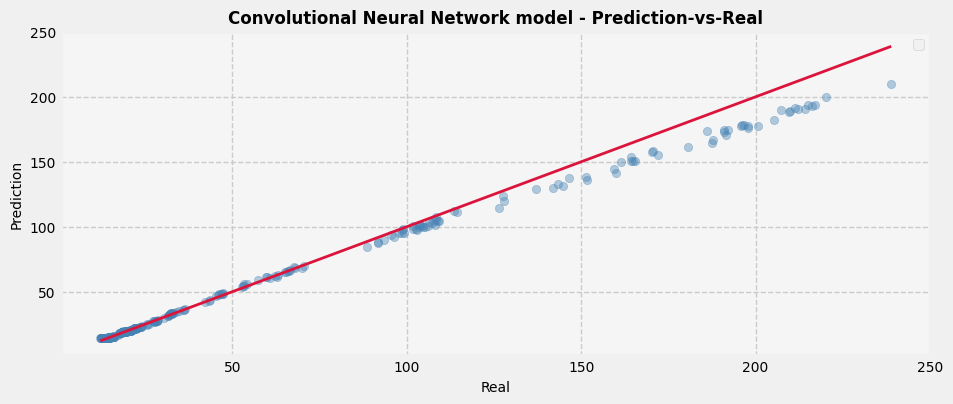

In [24]:
# Prediction-vs-Real
fig = plt.figure(figsize = (10, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
ax.scatter(Y_test, y_test_pred, color = 'steelblue', alpha = 0.4)
ax.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color = 'crimson', linewidth = 2) # reference line
ax.set_ylabel('Prediction', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
ax.set_xlabel('Real', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
plt.title('Convolutional Neural Network model - Prediction-vs-Real', fontsize = 12, fontweight = 'bold')
plt.grid(linestyle = '--')
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

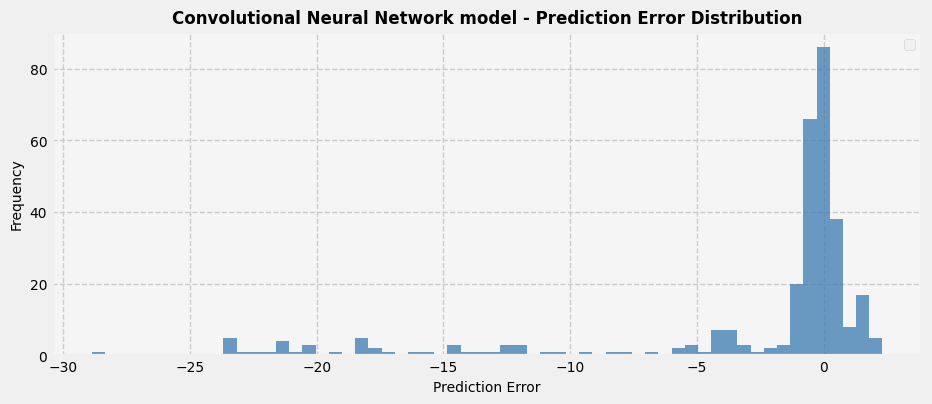

In [25]:
# Prediction Error
errors = y_test_pred - Y_test
fig = plt.figure(figsize = (10, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
ax.hist(errors, bins = 60, color = 'steelblue', alpha = 0.8)
ax.set_ylabel('Frequency', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
ax.set_xlabel('Prediction Error', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
plt.title('Convolutional Neural Network model - Prediction Error Distribution', fontsize = 12, fontweight = 'bold')
plt.grid(linestyle = '--')
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

Which is the **``best performing model``**?  

Let us recall that the best performing model in terms of **Machine Learning** was **Linear Regression (LR) model**, achieving a remarkably low $MAE = 0.3403$ and $MSE = 0.4164$, clearly outperforming the other models tested.  

- The **Neural Network (NN) model**: reached $MAE = 26.1072$ and $MSE = 1,792$. Despite being a more complex architecture capable of modeling non-linear relationships, it underperformed significantly compared to the simple yet effective **Linear Regression model** in this scenario.  

- The **Convolutional Neural Network (CNN) model**: obtained $MAE = 3.2129$ and $MSE = 47.8055$. While it performed better than the **NN model**, it still fell short of the performance achieved by **Linear Regression model**. This suggests that the **CNN structure**, often effective for spatial or sequential data, does not offer a clear benefit in this regression task.  

The **``Random Forest Regressor (RF) model``** remains the **best performing model**, offering the lowest error metrics and confirming that a simple linear approach is most suitable for this particular dataset.  

Additionally, advanced boosting models such as **XGBoost** or **LightGBM** are worth exploring, as they frequently outperform traditional models by better handling bias and variance — and could offer further performance improvements in future iterations.